Aprendizado de variedades (Manifold Learning) com fluxo de clusterização distribuída por tipo de característica é mais informativo do que o UMAP para conjuntos de dados clínicos tabulares

Importando as Libraries

In [1]:
import sys
import os

# Ajusta o caminho para encontrar os módulos do FDC
current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

print(f"Diretório atual: {current_dir}")
print(f"Diretório pai adicionado: {parent_dir}")

Diretório atual: c:\Users\janeb\OneDrive\Documentos\5periodo\projeto_madeiro\Clinical-database\FDC_Intermediate_Dimension\Jupyter notebooks
Diretório pai adicionado: c:\Users\janeb\OneDrive\Documentos\5periodo\projeto_madeiro\Clinical-database\FDC_Intermediate_Dimension


In [2]:
import subprocess
import sys

# Instala pacotes necessários que podem estar faltando
packages_to_install = ['yellowbrick']

for package in packages_to_install:
    try:
        __import__(package)
        print(f"✓ {package} já está instalado")
    except ImportError:
        print(f"Instalando {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])
        print(f"✓ {package} instalado com sucesso")

✓ yellowbrick já está instalado


In [3]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
import tensorflow as tf
from tensorflow import keras
import math
import umap.umap_ as umap
%config InlineBackend.figure_format = 'svg'

In [4]:
from cluster_val import *

Importando os dados

In [5]:
np.random.seed(42)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
data_with_target=pd.read_csv('../Datasets/survey lung cancer.csv')

Pré-processamento dos dados

In [6]:
data_with_target.isna().sum() #Detecta valores faltando por coluna

GENDER                   0
AGE                      0
SMOKING                  0
YELLOW_FINGERS           0
ANXIETY                  0
PEER_PRESSURE            0
CHRONIC DISEASE          0
FATIGUE                  0
ALLERGY                  0
WHEEZING                 0
ALCOHOL CONSUMING        0
COUGHING                 0
SHORTNESS OF BREATH      0
SWALLOWING DIFFICULTY    0
CHEST PAIN               0
LUNG_CANCER              0
dtype: int64

In [7]:
#Transforma variável categórica (F/M) em numérica (1/0) -> label encoding manual
gender_mod= {'GENDER': {'F':1,'M':0}}
data_with_target.replace(gender_mod,inplace=True)
data_with_target['GENDER']

0      0
1      0
2      1
3      0
4      1
      ..
304    1
305    0
306    0
307    0
308    0
Name: GENDER, Length: 309, dtype: int64

In [8]:
np.random.seed(42)
data_with_target=data_with_target.sample(frac=1) #Shuffle the data set
np.random.seed(42)
i=[x for x in range(309)]

data_with_target.set_index(pd.Series(i), inplace=True)

In [9]:
data_with_target['LUNG_CANCER']

0      YES
1      YES
2      YES
3      YES
4      YES
      ... 
304    YES
305    YES
306    YES
307     NO
308    YES
Name: LUNG_CANCER, Length: 309, dtype: object

In [10]:
data=data_with_target.drop(['LUNG_CANCER'],axis=1)

In [11]:
data.shape

(309, 15)

UMAP nos dados originais

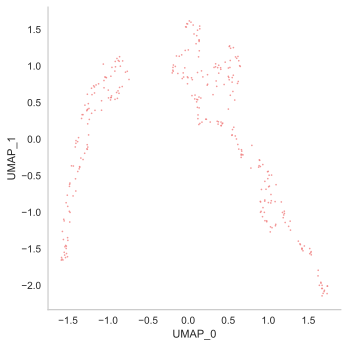

In [12]:
from fdc.fdc import feature_clustering

umap_emb=feature_clustering(15,0.1,'euclidean',data,True)

Silhouette_score e Dunn index para clusters UMAP extraidos usando k-means

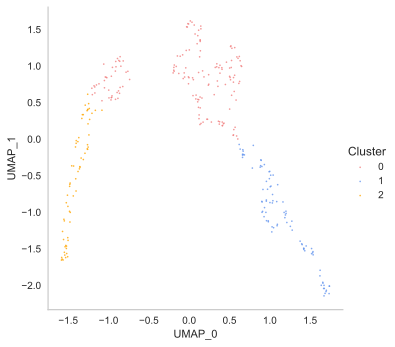

In [13]:
from fdc.clustering import Clustering

umap_clustering=Clustering(umap_emb,umap_emb,True)
umap_cluster_list,umap_cluster_counts=umap_clustering.K_means(3)

In [14]:
from sklearn import metrics
from sklearn.metrics import pairwise_distances
from sklearn.metrics import silhouette_score

silhouette_score(umap_emb, umap_cluster_list, metric='euclidean')

0.6569111550668095

Visualizing Silhouette score (Pode-se escolher o número de clusters baseado no score)

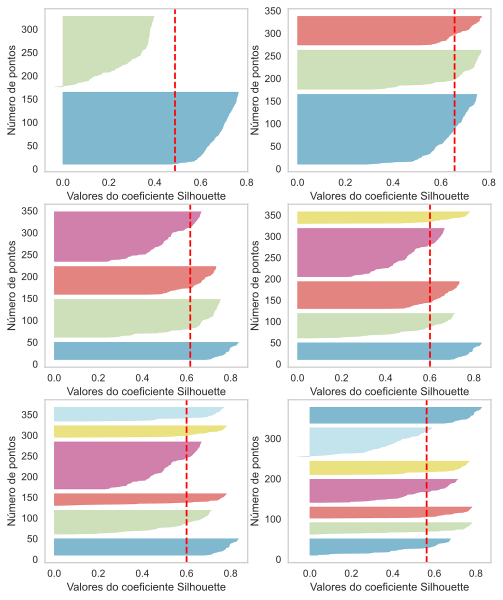

In [15]:
Silhouette_visual(umap_emb)

Elbow plot para o umap_embedding

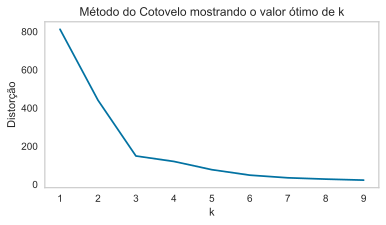

In [16]:
elbow_plot(umap_emb)

In [17]:
dunn_index(cluster_wise_df(umap_emb,umap_cluster_list))

0.0331734241671445

Silhouette_score e Dunn index para clusters UMAP extraidos usando clustering Aglomerativo

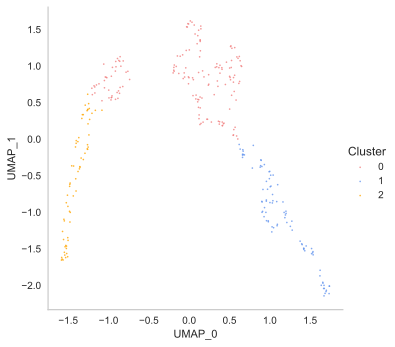

In [18]:
umap_cluster_list_agglo,umap_cluster_counts_agglo=umap_clustering.Agglomerative(3,'euclidean','ward')

In [19]:
silhouette_score(umap_emb, umap_cluster_list_agglo, metric='euclidean')

0.6569111550668095

In [20]:
dunn_index(cluster_wise_df(umap_emb,umap_cluster_list_agglo))

0.0331734241671445

Silhouette_score e Dunn index para clusters UMAP extraidos usando clustering do DBSCAN

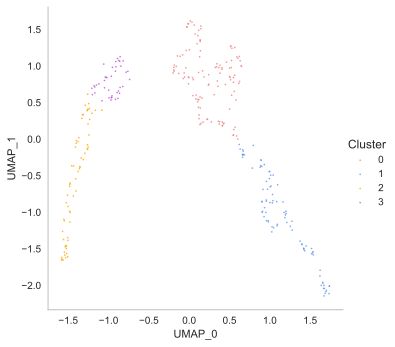

In [21]:
umap_cluster_list_dbscan,umap_cluster_counts_dbscan=umap_clustering.DBSCAN(0.5,20)

In [22]:
#Remove os indices considerados ruídos pelo algoritmo
non_noise_indices= np.where(np.array(umap_cluster_list_dbscan)!=-1)
umap_emb= umap_emb.iloc[non_noise_indices]
#FDC_emb_low= FDC_emb_low.iloc[non_noise_indices]
umap_cluster_list_dbscan= np.array(umap_cluster_list_dbscan)[non_noise_indices]

In [23]:
silhouette_score(umap_emb, umap_cluster_list_dbscan, metric='euclidean')

0.6689165988372793

In [24]:
dunn_index(cluster_wise_df(umap_emb,umap_cluster_list_dbscan))

0.02491907115608306

Dividindo as variaveis
- cont_list = continuas
- ord_list = ordinais
-  nom_list  = nominais

In [25]:
cont_list=['AGE']

ord_list=['SMOKING','GENDER','CHRONIC DISEASE','ALCOHOL CONSUMING','SHORTNESS OF BREATH']

nom_list=['YELLOW_FINGERS','ANXIETY','PEER_PRESSURE','WHEEZING','COUGHING','SWALLOWING DIFFICULTY','CHEST PAIN','FATIGUE ','ALLERGY ']

In [26]:
len(ord_list)

5

In [27]:
len(nom_list)

9

In [28]:
len(cont_list)

1

Usando FDC nos dados originais

In [29]:
from fdc.fdc import FDC, Clustering
from fdc.fdc import canberra_modified
modified_can = canberra_modified

FDC.normalize (init): 0.00000 / 0.000s
FDC.normalize (clustering CONT): 2.28125 / 2.281s
FDC.normalize (clustering ORD): 2.07812 / 4.359s
FDC.normalize (clustering NOM): 1.43750 / 5.797s
FDC.normalize (concat): 0.00000 / 5.797s
FDC.normalize (umap 5 -> 2): 0.73438 / 6.531s
FDC.normalize (array -> DataFrame): 0.00000 / 6.531s


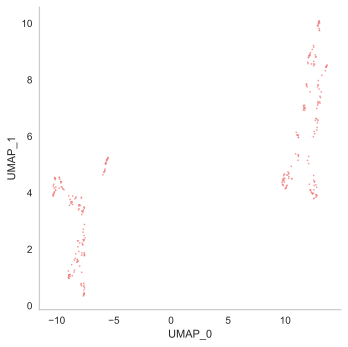

FDC.normalize (plotting): 0.76562 / 7.297s
FDC.normalize (array -> DataFrame): 0.00000 / 7.297s
FDC.normalize (total): 0.00000 / 7.297s


In [30]:
fdc = FDC(
    clustering_cont=Clustering('euclidean', 15, 0.1, max_components=1)  # usa distância euclidiana para variáveis contínuas
    , clustering_ord=Clustering('canberra', 15, 0.1)                    # usa distância de Canberra para variáveis ordinais
    , clustering_nom=Clustering('hamming', 15, 0.1)                     # usa distância de Hamming para variáveis nominais (categóricas sem ordem)
    , visual=True              # ativa visualização automática dos clusters e embeddings
    , use_pandas_output=True   # faz o retorno ser em formato de DataFrame do pandas
    , with_2d_embedding=True   # gera uma projeção em 2D para visualização dos dados
)

fdc.selectFeatures(
    continueous=cont_list,
    nomial=nom_list,
    ordinal=ord_list
) # informa ao modelo quais variáveis são contínuas, nominais e ordinais


FDC_emb_high, FDC_emb_low = fdc.normalize(
    data,
    n_neighbors=30, # número de vizinhos usados na construção do grafo (mais alto → clusters mais globais)
    min_dist=0.001, # controla o quão próximos os pontos podem ficar no embedding, valor muito baixo → clusters muito compactos e bem definidos
    cont_list=cont_list,
    nom_list=nom_list,
    ord_list=ord_list,
    with_2d_embedding=True, #Gera duas representações, uma de alta e outra de baixa dimensão
    visual=True # exibe visualizações automáticas dos clusters e embeddings
)

In [31]:
# salva embeddings originais antes do DBSCAN modificar
FDC_emb_high_original = FDC_emb_high.copy()
FDC_emb_low_original = FDC_emb_low.copy()

Silhouette_score e Dunn index para clusters FDC(Dimensão intermediária) extraidos usando clustering do K-means

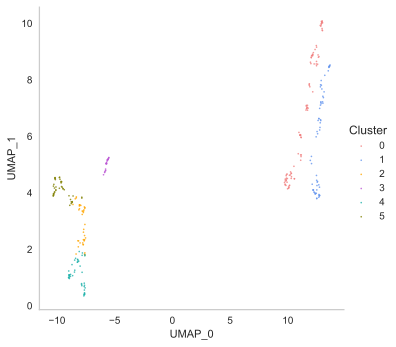

In [32]:
from fdc.clustering import Clustering

clustering=Clustering(FDC_emb_high,FDC_emb_low,True)
cluster_list,cluster_counts=clustering.K_means(6)

In [33]:
FDC_emb_high['Cluster'] = cluster_list

In [34]:
silhouette_score(FDC_emb_high, cluster_list, metric='euclidean')

0.39958930690594874

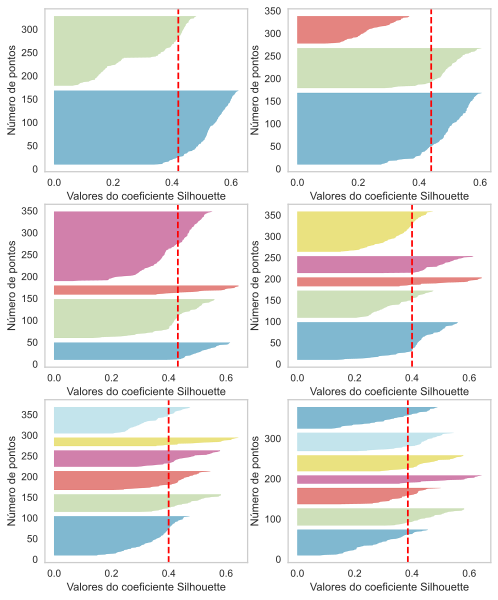

In [35]:
Silhouette_visual(FDC_emb_high)

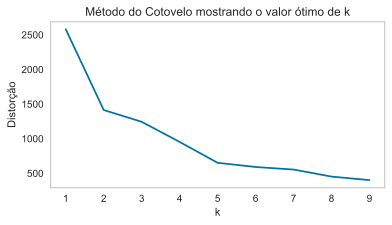

In [36]:
elbow_plot(FDC_emb_high)

In [37]:
dunn_index(cluster_wise_df(FDC_emb_high,cluster_list))

0.18811379876148493

Silhouette_score e Dunn index para clusters FDC(Dimensão intermediária) extraidos usando clustering Aglomerativo

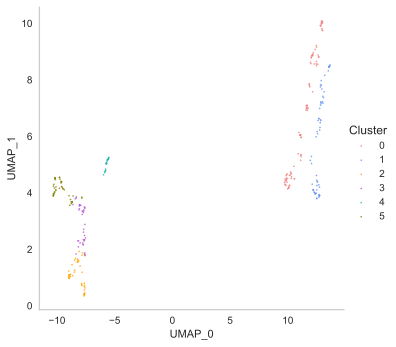

In [38]:
cluster_list_agglo,cluster_counts_agglo=clustering.Agglomerative(6,'euclidean','ward')

In [39]:
FDC_emb_high['Cluster'] = cluster_list_agglo

In [40]:
silhouette_score(FDC_emb_high, cluster_list_agglo, metric='euclidean')

0.4063504439763937

In [41]:
dunn_index(cluster_wise_df(FDC_emb_high,cluster_list_agglo))

0.10568673451030834

Silhouette_score e Dunn index para clusters FDC(Dimensão intermediária) extraidos usando clustering do DBSCAN

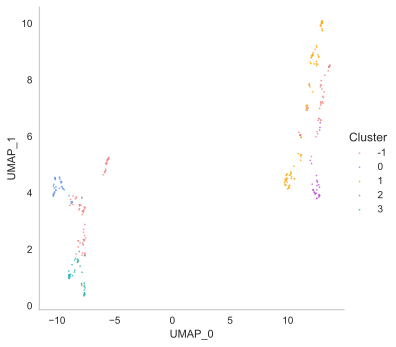

In [42]:
cluster_list_dbscan,cluster_counts_dbscan=clustering.DBSCAN(1.2,20)

In [43]:
cluster_counts_dbscan

array([118,  38,  82,  31,  40])

In [44]:
FDC_emb_high['Cluster'] = cluster_list_dbscan

In [45]:
cluster_list_dbscan_original = list(cluster_list_dbscan)

In [46]:
#Remove indices considerados ruídos
non_noise_indices= np.where(np.array(cluster_list_dbscan)!=-1)
FDC_emb_high= FDC_emb_high.iloc[non_noise_indices]
FDC_emb_low= FDC_emb_low.iloc[non_noise_indices]
cluster_list_dbscan= np.array(cluster_list_dbscan)[non_noise_indices]

In [47]:
silhouette_score(FDC_emb_high, cluster_list_dbscan, metric='euclidean') #média de separação ponto a ponto

0.4811776795107479

In [48]:
dunn_index(cluster_wise_df(FDC_emb_high,cluster_list_dbscan)) #pior caso de separação vs pior dispersão

0.23804806389687164

Pacientes perdidos como ruído: 44 de 309
Clusters encontrados: 4


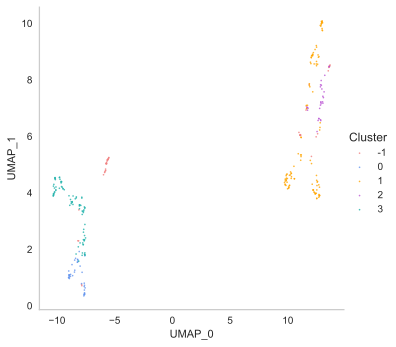

,Silhouette,Dunn,ANOVA (% features significativas),Pacientes perdidos
K-means,0.300,0.188,83.33,0.0
DBSCAN,0.151,0.238,83.33,118.0
HDBSCAN,0.208,0.074,100.00,44.0


In [49]:
from sklearn.metrics import silhouette_score
from scipy.stats import f_oneway, kruskal

hdbscan_cluster_list, hdbscan_cluster_counts = clustering.HDBSCAN(min_cluster_size=15)

non_noise = [i for i, x in enumerate(hdbscan_cluster_list) if x != -1]
hdbscan_emb = FDC_emb_high_original.iloc[non_noise]
hdbscan_labels = [hdbscan_cluster_list[i] for i in non_noise]
hdbscan_data = data.iloc[non_noise]

resultados = {
    'K-means': {
        'Silhouette': round(silhouette_score(FDC_emb_high_original, cluster_list), 3),
        'Dunn': round(dunn_index(cluster_wise_df(pd.DataFrame(FDC_emb_high_original).assign(Cluster=cluster_list), cluster_list)), 3),
        'ANOVA (% features significativas)': calcular_anova(data, cluster_list, cont_list, ord_list),
        'Pacientes perdidos': 0
    },
    'DBSCAN': {
        'Silhouette': round(silhouette_score(FDC_emb_high_original, cluster_list_dbscan_original), 3),
        'Dunn': round(dunn_index(cluster_wise_df(pd.DataFrame(FDC_emb_high_original).assign(Cluster=cluster_list_dbscan_original), cluster_list_dbscan_original)), 3),
        'ANOVA (% features significativas)': calcular_anova(data, cluster_list_dbscan_original, cont_list, ord_list),
        'Pacientes perdidos': sum(1 for x in cluster_list_dbscan_original if x == -1)
    },
    'HDBSCAN': {
        'Silhouette': round(silhouette_score(hdbscan_emb, hdbscan_labels), 3),
        'Dunn': round(dunn_index(cluster_wise_df(pd.DataFrame(hdbscan_emb).assign(Cluster=hdbscan_labels), hdbscan_labels)), 3),
        'ANOVA (% features significativas)': calcular_anova(hdbscan_data, hdbscan_labels, cont_list, ord_list),
        'Pacientes perdidos': sum(1 for x in hdbscan_cluster_list if x == -1)
    }
}

pd.DataFrame(resultados).T